In [1]:
import numpy as np
from tensorflow.keras.optimizers import Adam
from keras.layers import Activation, Dropout, Convolution2D, GlobalAveragePooling2D
from keras.models import Sequential
import tensorflow as tf
import tensorflow.keras.applications.mobilenet
import os
import PIL
import cv2
import keras
import matplotlib.pyplot as plt
from keras import layers
from keras import Model
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

IMG_SAVE_PATH_Test = 'dataset'
folders = [name for name in os.listdir(IMG_SAVE_PATH_Test) if os.path.isdir(os.path.join(IMG_SAVE_PATH_Test, name))]
folders_dict = {folder: index for index, folder in enumerate(folders)}
folders_dict

Str_to_Int = folders_dict

NUM_CLASSES = 8
def str_to_Int_mapper(val):
    return Str_to_Int[val]
angle_mapping = {
    "right": 0,
    "front_left": 130,
    "left": 180,
    "rear_left": 230,
    "rear": 270,
    "rear_right": 320,
    "front_right": 40,
    "front": 90
}
angle_to_name = {v: k for k, v in angle_mapping.items()}

def preprocess(IMG_SAVE_PATH, limit=500):
    dataset = []
    for directory in os.listdir(IMG_SAVE_PATH):
        path = os.path.join(IMG_SAVE_PATH, directory)
        if not os.path.isdir(path):
            continue  
        count = 0
        for image in os.listdir(path):
            if count >= limit:
                break
            new_path = os.path.join(path, image)
            try:
                imgpath = PIL.Image.open(new_path)
                imgpath = imgpath.convert('RGB')
                img = np.asarray(imgpath)
                img = cv2.resize(img, (331, 331))
                img = img / 255.0
                dataset.append([img, directory])
                count += 1
            except FileNotFoundError:
                print(f'Image file not found: {new_path}. Skipping...')
            except Exception as e:
                print(f'Error processing {new_path}: {e}')
    return dataset
traindata=preprocess(IMG_SAVE_PATH_Test)

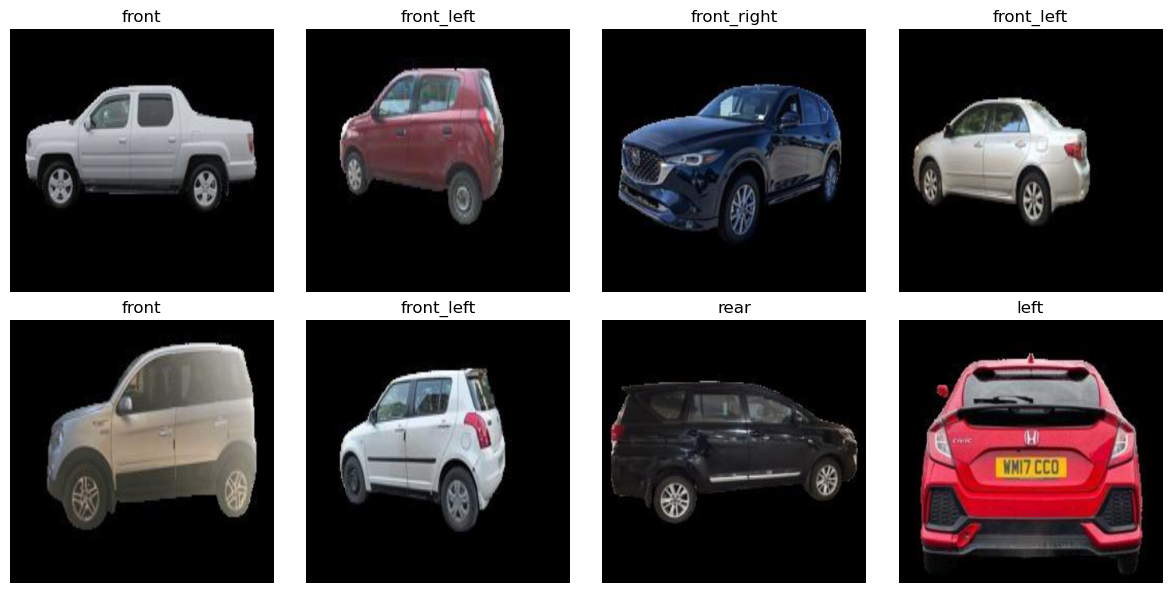

In [3]:
xtest, labelstest = zip(*traindata)

import matplotlib.pyplot as plt
import random


indices = random.sample(range(len(xtest)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    plt.subplot(2, 4, i + 1)  
    plt.imshow(xtest[idx])  
    plt.title(angle_to_name[int(labelstest[idx])])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [4]:
model = tf.keras.models.load_model('model.keras')
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 331, 331, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_209 (Conv2D)           │ (None, 165, 165, 32)      │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_203       │ (None, 165, 165, 32)      │              96 │ conv2d_209[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_209 (Activation)   │ (None, 165, 165, 32)      │               0 │ batch_normalization_203[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_210 (Conv2D)           │ (None, 163, 163, 32)      │           9,216 │ activation_209[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_204       │ (None, 163, 163, 32)      │              96 │ conv2d_210[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_210 (Activation)   │ (None, 163, 163, 32)      │               0 │ batch_normalization_204[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_211 (Conv2D)           │ (None, 163, 163, 64)      │          18,432 │ activation_210[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_205       │ (None, 163, 163, 64)      │             192 │ conv2d_211[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_211 (Activation)   │ (None, 163, 163, 64)      │               0 │ batch_normalization_205[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 81, 81, 64)        │               0 │ activation_211[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_212 (Conv2D)           │ (None, 81, 81, 80)        │           5,120 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_206       │ (None, 81, 81, 80)        │             240 │ conv2d_212[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_212 (Activation)   │ (None, 81, 81, 80)        │               0 │ batch_normalization_206[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_213 (Conv2D)           │ (None, 79, 79, 192)       │         138,24

 Total params: 395,543,322 (1.47 GB)

 Trainable params: 113,735,528 (433.87 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

 Optimizer params: 227,471,058 (867.73 MB)

In [5]:
temp1 = list(map(str_to_Int_mapper, labelstest))
xtest=np.array(xtest)
ytest = tensorflow.keras.utils.to_categorical(temp1)
Y=np.array(ytest)

In [6]:
Y_pred = model.predict([xtest, xtest])

125/125 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step


In [7]:
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_pred,axis = 1) 
Y_pred_max_prob = np.max(Y_pred, axis=1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(Y,axis = 1) 

In [8]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
        

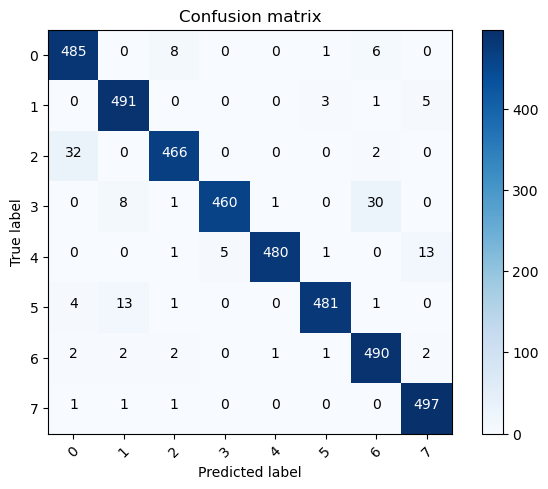

In [9]:
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.metrics import confusion_matrix
import itertools
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(8))


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Compute accuracy
accuracy = accuracy_score(Y_true, Y_pred_classes)
print("Accuracy:", accuracy)

# Compute precision
precision = precision_score(Y_true, Y_pred_classes, average='weighted')
print("Precision:", precision)

# Compute recall
recall = recall_score(Y_true, Y_pred_classes, average='weighted')
print("Recall:", recall)

# Compute F1-score
f1 = f1_score(Y_true, Y_pred_classes, average='weighted')
print("F1 Score:", f1)


Accuracy: 0.9625
Precision: 0.963553137339155
Recall: 0.9625
F1 Score: 0.9625312286281879


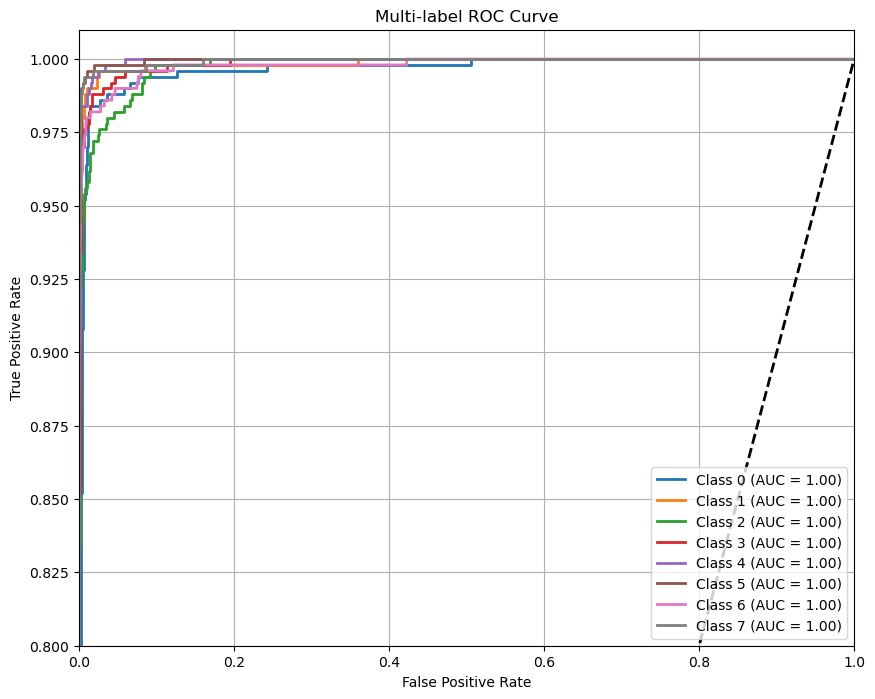

In [11]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = Y.shape[1]

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(Y[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.8, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-label ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
